# Synthetic Stress Model (Baseline)

This notebook constructs a proxy “stress” signal based on the difference
between wind generation and demand.

The goal is to explore how logistic regression behaves when the target
is directly derived from input features.

This serves as a sanity check for modelling behaviour, rather than a
realistic representation of system constraints.

Key result:
The model achieves high predictive performance because the target is
constructed from the input variables.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/modelling_dataset.csv")

print(df.shape)
df.head()

(17479, 5)


,sp_key,sw_demand_mw,wind_mw,date,sp
0,2022-01-01_5,1020.0,12551.785714,2022-01-01,5
1,2022-01-01_43,1329.1,13253.375000,2022-01-01,43
2,2022-01-01_44,1261.2,13103.625000,2022-01-01,44
3,2022-01-01_45,1201.7,12953.875000,2022-01-01,45
4,2022-01-01_46,1154.0,12798.937500,2022-01-01,46


In [3]:
df['date'] = df['sp_key'].str[:10]
df['sp'] = df['sp_key'].str.split("_").str[1].astype(int)

df = df.sort_values(['date', 'sp']).reset_index(drop=True)

In [4]:
df['interaction'] = df['wind_mw'] * df['sw_demand_mw']

In [5]:
df = df.dropna().reset_index(drop=True)

In [6]:
np.random.seed(42)

df['stress_signal'] = df['wind_mw'] - df['sw_demand_mw']
df['stress_signal'] += np.random.normal(0, 300, len(df))

threshold = df['stress_signal'].quantile(0.9)

df['stress_event'] = (df['stress_signal'] >= threshold).astype(int)

In [7]:
X = sm.add_constant(df[['wind_mw', 'sw_demand_mw']])
y = df['stress_event']

model_ignition = sm.Logit(y, X).fit()
print(model_ignition.summary())

Optimization terminated successfully.
         Current function value: 0.028825
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:           stress_event   No. Observations:                17479
Model:                          Logit   Df Residuals:                    17476
Method:                           MLE   Df Model:                            2
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.9113
Time:                        14:48:45   Log-Likelihood:                -503.83
converged:                       True   LL-Null:                       -5682.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -79.4212      3.677    -21.600      0.000     -86.628     -72.215
wind_mw          0.006

The model shows a strong relationship between wind and stress,
and a negative relationship with demand.

However, this reflects the construction of the target variable,
rather than independent predictive power.

The model is effectively recovering the definition of stress_event.

In [8]:
df['interaction'] = df['wind_mw'] * df['sw_demand_mw']

X = sm.add_constant(df[['wind_mw', 'sw_demand_mw', 'interaction']])
y = df['stress_event']

model_interaction = sm.Logit(y, X).fit()

print(model_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.028782
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:           stress_event   No. Observations:                17479
Model:                          Logit   Df Residuals:                    17475
Method:                           MLE   Df Model:                            3
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.9115
Time:                        14:48:47   Log-Likelihood:                -503.07
converged:                       True   LL-Null:                       -5682.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -64.7513     12.352     -5.242      0.000     -88.961     -40.541
wind_mw          0.005

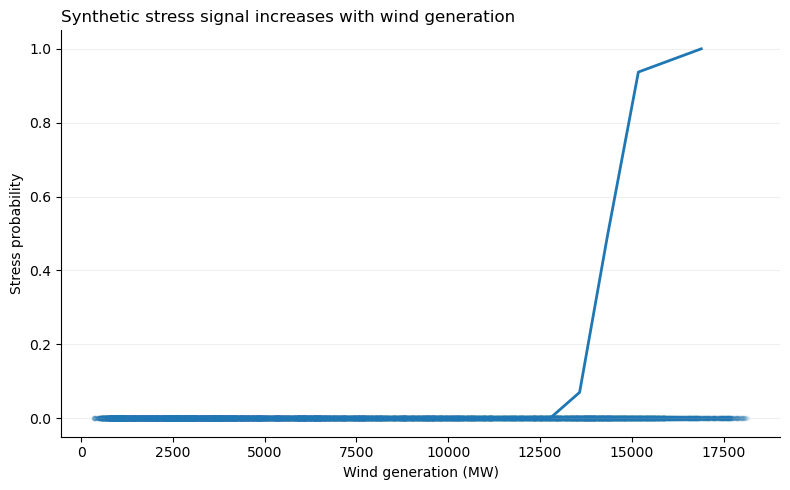

In [9]:
# =========================
# WIND CURVE (TUFTE STYLE)
# =========================

df['wind_bucket'] = pd.qcut(df['wind_mw'], 25)

wind_curve = (
    df.groupby('wind_bucket', observed=True)['stress_event']
    .mean()
    .reset_index()
)

wind_curve['wind_mid'] = wind_curve['wind_bucket'].apply(lambda x: x.mid)

# --- Plot ---
plt.figure(figsize=(8,5))

plt.plot(
    wind_curve['wind_mid'],
    wind_curve['stress_event'],
    linewidth=2
)

# Tufte styling
plt.xlabel("Wind generation (MW)")
plt.ylabel("Stress probability")

plt.title("Synthetic stress signal increases with wind generation", loc='left')

plt.grid(axis='y', alpha=0.2)
plt.grid(axis='x', alpha=0)

# remove spines
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.scatter(df['wind_mw'], np.zeros(len(df)), alpha=0.07, s=9)

plt.tight_layout()

plt.show()

In this synthetic framework, stress probability increases with wind generation,
reflecting the constructed relationship between inputs and the target variable.

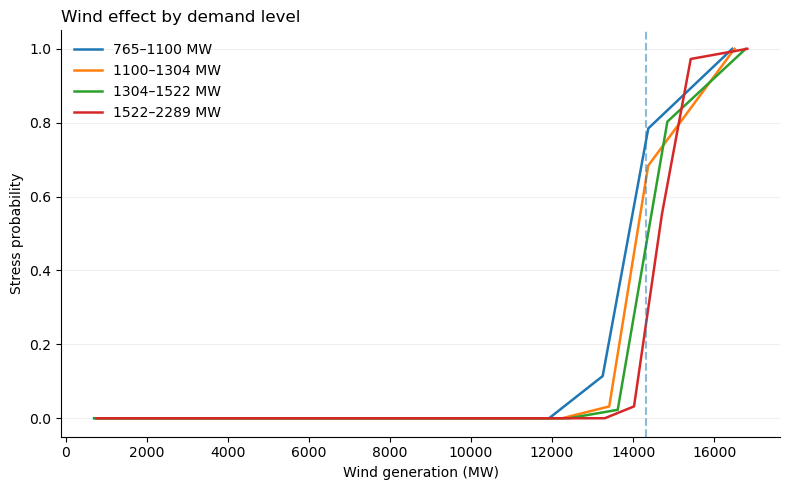

In [10]:
# =========================
# STRATIFIED WIND CURVES
# =========================

df['demand_bucket'] = pd.qcut(df['sw_demand_mw'], 4)

plt.figure(figsize=(8,5))

for label, group in df.groupby('demand_bucket', observed=True):
    
    temp = group.copy()
    temp['wind_bucket'] = pd.qcut(temp['wind_mw'], 20)
    
    curve = (
        temp.groupby('wind_bucket', observed=True)['stress_event']
        .mean()
        .reset_index()
    )
    
    curve['wind_mid'] = curve['wind_bucket'].apply(lambda x: x.mid)
    
    plt.plot(
        curve['wind_mid'],
        curve['stress_event'],
        linewidth=1.8,
        label=f"{round(label.left)}–{round(label.right)} MW"
    )

# Tufte styling
plt.xlabel("Wind generation (MW)")
plt.ylabel("Stress probability")

plt.title("Wind effect by demand level", loc='left')

plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.2)
plt.grid(axis='x', alpha=0)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

threshold = df['wind_mw'].quantile(0.9)

plt.axvline(threshold, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Stratification by demand shows limited separation between curves,
as demand is already embedded in the stress definition.

This further highlights that the model reflects the engineered signal
rather than independent system dynamics.

The probability of the synthetic stress event increases with wind generation,
as expected given the construction of the target variable.

This confirms that the model is capturing the engineered relationship,
rather than discovering new system behaviour.

While this synthetic model behaves as expected, it is not based on
real system signals.

The next step introduces a market-based proxy using system prices,
which provides a more realistic (though still imperfect) measure of
system stress.